# Heterogeneity Suite (suite4)

The heterogeneity pillar controls **background intensity structure**.

| Level | Background | Character |
|-------|-----------|-----------|
| H0 | constant rate | homogeneous Poisson baseline |
| H1 | stationary 3-cluster GMM | fixed spatial hotspots |
| H2 | moving Gaussian hotspot | drifting source |
| H3 | Gabor traveling wave | structured spatio-temporal pattern |

The triggering kernel is fixed (separable, η = 0.40) across all levels.
Only the exogenous arrival rate μ(s, t) changes.


In [1]:
from hawkesnest.suites import HeterogeneitySuite
from hawkesnest.config import SimulatorConfig
from hawkesnest.viz import (plot_kde_panels, plot_suite_event_grid,
                             plot_intensity_snapshots)
import matplotlib.pyplot as plt

suite = HeterogeneitySuite()
results = [suite.generate(level=lv, n_events=300, seed=0) for lv in suite.levels()]
{r.level: r.n_events for r in results}


{'H0': 300, 'H1': 300, 'H2': 300, 'H3': 300}

## Primary — background intensity surfaces

Evaluate μ(s, t) on a spatial grid at three time snapshots. This is the ground-truth diagnostic: it directly shows what each level's background looks like, independent of sampling noise.

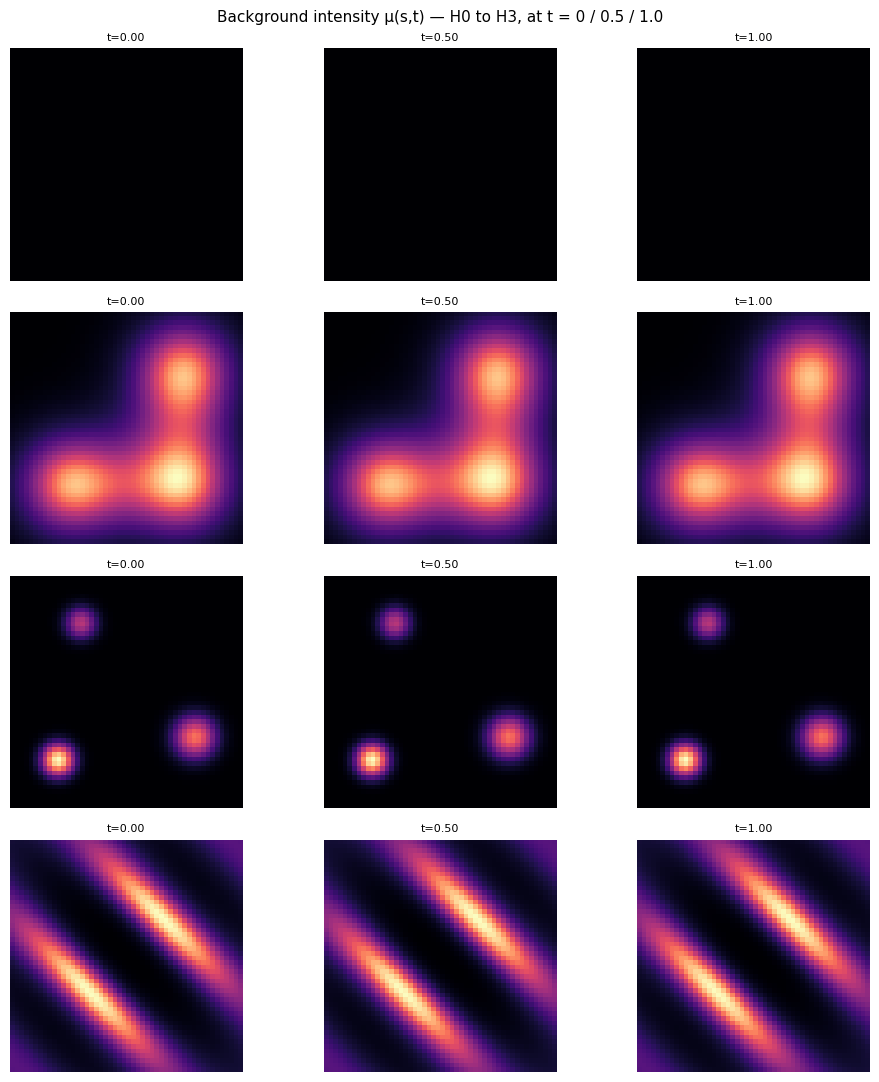

In [2]:
fig, all_axes = plt.subplots(4, 3, figsize=(10, 11))

for row, result in enumerate(results):
    cfg_dict = {k: v for k, v in result.config.items() if not k.startswith("_")}
    cfg_dict.pop("tau_max", None)
    sim = SimulatorConfig.model_validate(cfg_dict).build()
    bg = sim.background  # callable (s, t, mark) -> float

    snap_fig, snap_axes = plot_intensity_snapshots(
        lambda s, t, _bg=bg: _bg(s, t, 1),
        times=[0.0, 0.5, 1.0],
        n_grid=50, cmap="magma",
        title=f"{result.level}: {result.config['backgrounds'][0].get('name', result.config['backgrounds'][0]['type'])}",
    )
    # copy into subplot grid
    for col, src_ax in enumerate(snap_axes):
        src_ax.figure.canvas.draw()
        all_axes[row, col].imshow(
            src_ax.get_images()[0].get_array(),
            origin="lower", aspect="equal",
            extent=[0,1,0,1], cmap="magma",
        )
        all_axes[row, col].set_title(src_ax.get_title(), fontsize=8)
        all_axes[row, col].axis("off")
    plt.close(snap_fig)

fig.suptitle("Background intensity μ(s,t) — H0 to H3, at t = 0 / 0.5 / 1.0", fontsize=11)
fig.tight_layout()
plt.show()


## Primary (alternative) — smooth KDE density across levels

KDE of event locations shows how the background structure shapes the spatial distribution of arrivals.

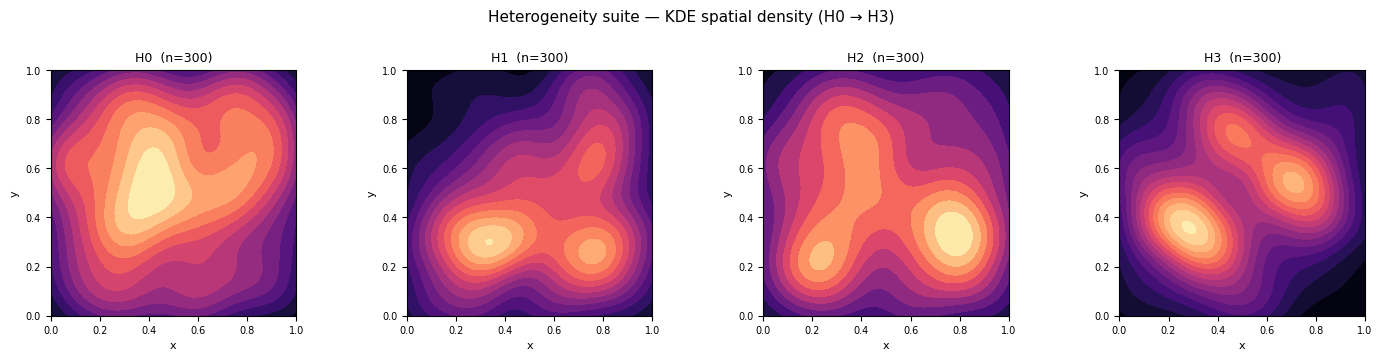

In [3]:
fig = plot_kde_panels(results, cmap="magma",
                      title="Heterogeneity suite — KDE spatial density (H0 → H3)")
plt.show()


## Secondary — 2D event scatter coloured by arrival time

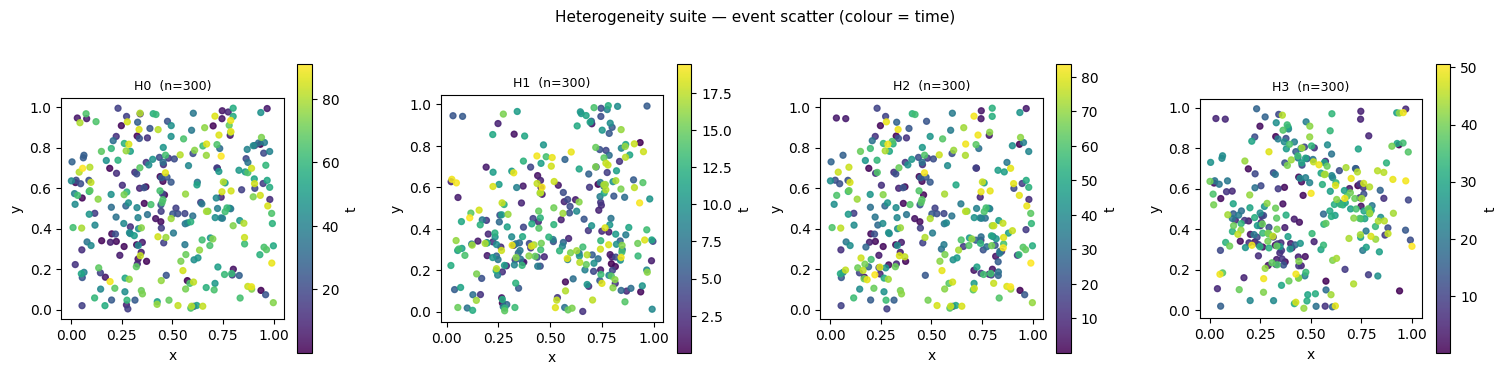

In [4]:
fig = plot_suite_event_grid(results, color_by="t", cmap="viridis",
                            title="Heterogeneity suite — event scatter (colour = time)")
plt.show()
